# 00 - Preprocesamiento de radiografías

**Proyecto:** Detección automática de fracturas óseas en radiografías  
**Materia:** Visión por Computadora II - CEIA/FIUBA  
**Autores:** Lucia T. Capon Paul · César Andrés Orellana · Leandro Britez

En este notebook analizamos dos configuraciones candidatas de preprocesamiento y, después de compararlas visualmente, generamos un único dataset final. El objetivo es mejorar la visibilidad de las estructuras óseas sin cambiar la geometría de la radiografía ni las cajas anotadas.

### ¿Por qué aplicamos estas técnicas?

Las radiografías pueden tener distintos niveles de brillo y contraste según el equipo, la posición del paciente o la exportación de la imagen. Una fractura puede aparecer como una línea fina y con poco contraste respecto del hueso. Por eso consideramos tres pasos moderados:

- **Normalización robusta por percentiles:** descartamos los valores de intensidad más extremos (percentiles 1 y 99) y reescalamos el resto. Así evitamos que unos pocos píxeles demasiado oscuros o claros dominen la imagen y logramos un rango de intensidades más comparable entre radiografías.
- **CLAHE:** mejora el contraste en zonas pequeñas de la imagen. Esto puede hacer más visibles detalles locales del hueso, pero si es muy intenso también puede aumentar el ruido.
- **Unsharp masking:** refuerza bordes usando la diferencia entre la imagen y una versión suavizada. Puede resaltar transiciones sutiles, pero con demasiada intensidad podría crear bordes artificiales.

### Relación con el paper guía

Tomamos como antecedente el trabajo de Srinivasu *et al.* (2025), *Exploring the impact of hyperparameter and data augmentation in YOLO V10 for accurate bone fracture detection from X-ray images*. Los autores aplican **CLAHE** y **unsharp masking** antes de entrenar YOLOv10 y reportan una mejora moderada respecto de las imágenes sin procesamiento.

No copiamos el método de forma automática. Agregamos normalización robusta por percentiles para reducir diferencias extremas de exposición y comparamos dos intensidades de realce. La referencia completa está disponible en `Paper_guia.pdf` y `paper_guia.md`.

> Importante: este preprocesamiento es determinista. Se aplica igual a train, valid y test. Los aumentos aleatorios se reservan para el entrenamiento.

## 1. Importar las librerías

En este paso importamos las librerías para leer las imágenes, visualizar la comparación y reutilizar las funciones de preprocesamiento implementadas en `src/`.

In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
from src.preprocessing import (
    PreprocessingConfig,
    create_preprocessed_dataset,
    preprocess_xray,
)


## 2. Definir las rutas

Usamos el dataset original como entrada. La carpeta de salida se utilizará sólo después de elegir la configuración final. El notebook se detiene si esa carpeta ya existe para no sobrescribir un experimento anterior.

In [2]:
DATA_ROOT = Path('../data/bone-fracture-detection-4')
FINAL_OUTPUT_ROOT = Path('../data/bone-fracture-detection-4-preprocessed-p2')
SPLITS = ('train', 'valid', 'test')

assert DATA_ROOT.exists(), f'No se encontró el dataset en: {DATA_ROOT.resolve()}'

print(f'Dataset original: {DATA_ROOT.resolve()}')
print(f'Salida final elegida: {FINAL_OUTPUT_ROOT.resolve()}')

Dataset original: /Users/cesar/Documents/Especializacion/Cuarto Bimestre/Vision por Computadora II/VPCII_TP_CEIA/data/bone-fracture-detection-4
Salida final elegida: /Users/cesar/Documents/Especializacion/Cuarto Bimestre/Vision por Computadora II/VPCII_TP_CEIA/data/bone-fracture-detection-4-preprocessed-p2


## 3. Definir las dos configuraciones candidatas

Primero definimos P1 y P2 solamente como candidatos. En esta etapa todavía no guardamos un dataset completo.

- **P1:** sigue el realce inicial, con CLAHE `2.0` y afilado `0.4`.
- **P2:** mantiene la normalización, pero reduce CLAHE a `1.5` y el afilado a `0.25`. La propuesta es disminuir el granulado observado en P1 sin perder demasiado detalle óseo.

In [3]:
P1_CONFIG = PreprocessingConfig(
    low_percentile=1,
    high_percentile=99,
    clahe_clip_limit=2.0,
    clahe_tile_grid_size=(8, 8),
    unsharp_sigma=1.2,
    unsharp_amount=0.4,
    jpeg_quality=95,
)

P2_CONFIG = PreprocessingConfig(
    low_percentile=1,
    high_percentile=99,
    clahe_clip_limit=1.5,
    clahe_tile_grid_size=(8, 8),
    unsharp_sigma=1.0,
    unsharp_amount=0.25,
    jpeg_quality=95,
)

print('P1:', P1_CONFIG)
print('P2:', P2_CONFIG)

P1: PreprocessingConfig(low_percentile=1, high_percentile=99, clahe_clip_limit=2.0, clahe_tile_grid_size=(8, 8), unsharp_sigma=1.2, unsharp_amount=0.4, jpeg_quality=95)
P2: PreprocessingConfig(low_percentile=1, high_percentile=99, clahe_clip_limit=1.5, clahe_tile_grid_size=(8, 8), unsharp_sigma=1.0, unsharp_amount=0.25, jpeg_quality=95)


## 4. Comparar visualmente P1 y P2

Aplicamos ambas configuraciones sobre la misma radiografía de entrenamiento. Esta comparación nos permite verificar si el realce ayuda a distinguir la estructura ósea o si, por el contrario, aumenta demasiado el ruido. Esta celda no guarda nuevas imágenes: sólo permite elegir el candidato que vamos a exportar.

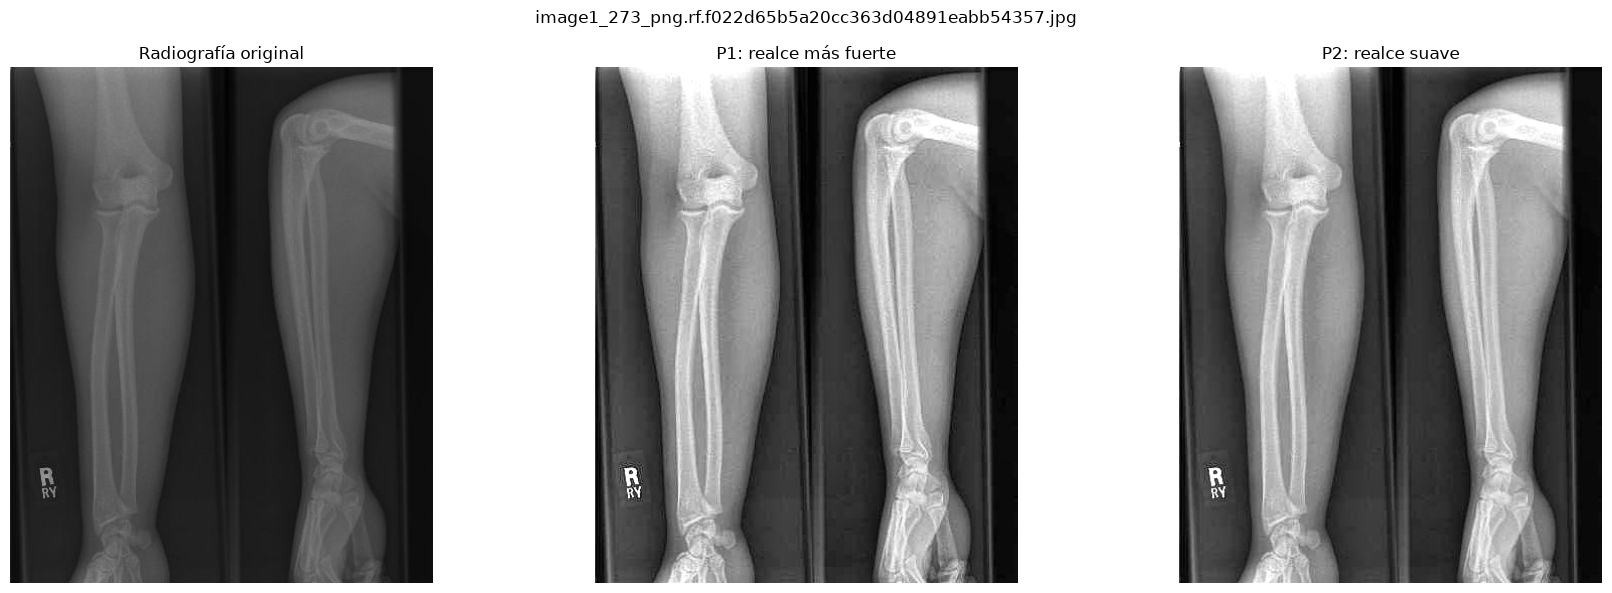

In [4]:
sample_path = next((DATA_ROOT / 'train' / 'images').glob('*.jpg'))
sample_bgr = cv2.imread(str(sample_path), cv2.IMREAD_COLOR)
assert sample_bgr is not None, f'No se pudo leer: {sample_path}'

sample_p1 = preprocess_xray(sample_bgr, P1_CONFIG)
sample_p2 = preprocess_xray(sample_bgr, P2_CONFIG)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
images = [sample_bgr, sample_p1, sample_p2]
titles = ['Radiografía original', 'P1: realce más fuerte', 'P2: realce suave']

for ax, image, title in zip(axes, images, titles):
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.suptitle(sample_path.name)
plt.tight_layout()
plt.show()

## 5. Decisión: elegir P2

En la comparación visual, P1 aumenta mucho el contraste, pero también resalta el granulado, los marcadores y zonas de fondo. P2 sigue mejorando la visibilidad de los bordes óseos, pero conserva una apariencia más cercana a la radiografía original.

Por este motivo elegimos **P2** para crear el dataset final. Esta decisión es una hipótesis basada en la inspección visual; la confirmaremos entrenando los modelos y comparando P2 contra el baseline sin preprocesamiento con las mismas particiones, hiperparámetros y métricas.

## 6. Crear un único dataset final con P2

Recién ahora procesamos todas las imágenes y las guardamos. Las etiquetas YOLO se copian sin modificación porque P2 no rota, no recorta ni redimensiona la radiografía; por lo tanto, las *bounding boxes* continúan siendo válidas.

In [5]:
assert not FINAL_OUTPUT_ROOT.exists(), (
    f'La salida final ya existe en: {FINAL_OUTPUT_ROOT.resolve()}. '
    'Elegir otra carpeta o revisar el experimento anterior antes de ejecutarlo de nuevo.'
)

summary = create_preprocessed_dataset(
    data_root=DATA_ROOT,
    output_root=FINAL_OUTPUT_ROOT,
    config=P2_CONFIG,
    splits=SPLITS,
)

summary

Procesando train:   0%|          | 0/3631 [00:00<?, ?it/s]

Procesando valid:   0%|          | 0/348 [00:00<?, ?it/s]

Procesando test:   0%|          | 0/169 [00:00<?, ?it/s]

[{'split': 'train', 'imagenes_procesadas': 3631, 'archivos_etiquetas': 3631},
 {'split': 'valid', 'imagenes_procesadas': 348, 'archivos_etiquetas': 348},
 {'split': 'test', 'imagenes_procesadas': 169, 'archivos_etiquetas': 169}]

## 7. Verificar el dataset exportado

Finalmente verificamos que se mantengan la misma cantidad de imágenes y etiquetas en cada partición. Esta validación evita continuar al entrenamiento con una exportación incompleta.

In [6]:
for split in SPLITS:
    original_images = len(list((DATA_ROOT / split / 'images').glob('*.jpg')))
    output_images = len(list((FINAL_OUTPUT_ROOT / split / 'images').glob('*.jpg')))
    original_labels = len(list((DATA_ROOT / split / 'labels').glob('*.txt')))
    output_labels = len(list((FINAL_OUTPUT_ROOT / split / 'labels').glob('*.txt')))

    assert original_images == output_images, f'Cantidad de imágenes distinta en {split}'
    assert original_labels == output_labels, f'Cantidad de etiquetas distinta en {split}'

    check_image = next((FINAL_OUTPUT_ROOT / split / 'images').glob('*.jpg'))
    assert cv2.imread(str(check_image), cv2.IMREAD_COLOR) is not None, (
        f'No se pudo volver a leer: {check_image}'
    )

print('Dataset P2 creado y validado correctamente.')
print(f'Dataset final: {FINAL_OUTPUT_ROOT / "data.yaml"}')

Dataset P2 creado y validado correctamente.
Dataset final: ../data/bone-fracture-detection-4-preprocessed-p2/data.yaml
